# 14 Ocurrence ML

This copy notebook models `P(observed / reported flooding complaint event)`.

The negative label means no observed 311 flood complaint during the matched event window. It is not proof of physical no-flooding.

Split rule:
- one classic stratified `75/15/10` train/validation/test split
- stratification prioritizes the target plus `mayoral_administration` when feasible
- model selection is a hyperparameter-grid sweep on train/validation; test is untouched final evaluation

Models are restricted to course-aligned supervised methods:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- optional XGBoost / LightGBM / CatBoost only if installed and already part of the workflow

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
from project_name.modeling_stage import (
    OCCURRENCE_BIAS_DIAGNOSTICS_PATH,
    OCCURRENCE_CALIBRATION_PATH,
    OCCURRENCE_FEATURE_IMPORTANCE_PATH,
    OCCURRENCE_LEAKAGE_AUDIT_PATH,
    OCCURRENCE_PREDICTIONS_PATH,
    OCCURRENCE_RESULTS_PATH,
    compact_modeling_summary,
    feature_catalog,
    load_modeling_frame,
    run_occurrence_ml,
    summarize_feature_groups,
    unavailable_expected_features,
)

balanced = load_modeling_frame(view_name="strict_main", include_geometry=False)
print(f"balanced rows: {len(balanced):,}")
print(balanced["occurrence"].value_counts(dropna=False).to_string())
display(summarize_feature_groups(balanced))
display(unavailable_expected_features(balanced))
display(feature_catalog(balanced).head(40))

balanced rows: 69,738
occurrence
True     34870
False    34868


,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.936914,0
1,extra,18,18,0.971959,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.971551,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.873828,0
9,terrain_coastal,8,8,0.999993,0


,feature_group,feature,available,dtype,non_null_rate,n_unique


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.495311,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,46215
9,extra,component_size,True,int64,1.000000,60


In [3]:
results, predictions, feature_importance = run_occurrence_ml(balanced)

display(compact_modeling_summary(results, ["pr_auc", "recall", "balanced_accuracy"]).head(30))
display(results.sort_values(["pr_auc", "recall"], ascending=False, kind="stable").head(30))
display(feature_importance.head(30))

print(f"saved: {OCCURRENCE_RESULTS_PATH}")
print(f"saved: {OCCURRENCE_PREDICTIONS_PATH}")
print(f"saved: {OCCURRENCE_FEATURE_IMPORTANCE_PATH}")
print(f"saved: {OCCURRENCE_BIAS_DIAGNOSTICS_PATH}")
print(f"saved: {OCCURRENCE_CALIBRATION_PATH}")
print("incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/occurrence")

/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/map10194/miniconda3/envs/urban-floo

,task_name,split_strategy,model_name,status,pr_auc,recall,balanced_accuracy,best_params,notes
0,occurrence,stratified_75_15_10,random_forest,ok,0.894834,0.837970,0.812876,"{""model__class_weight"": ""balanced"", ""model__ma...",Classic 75/15/10 split. Stratification priorit...
1,occurrence,stratified_75_15_10,gradient_boosting,ok,0.886635,0.831374,0.806424,"{""model__learning_rate"": 0.1, ""model__max_dept...",Classic 75/15/10 split. Stratification priorit...
2,occurrence,stratified_75_15_10,decision_tree,ok,0.791930,0.726699,0.729280,"{""model__criterion"": ""entropy"", ""model__max_de...",Classic 75/15/10 split. Stratification priorit...
3,occurrence,stratified_75_15_10,logistic_regression,ok,0.732782,0.641812,0.686980,"{""model__C"": 10.0, ""model__class_weight"": null}",Classic 75/15/10 split. Stratification priorit...


,task_name,split_strategy,model_name,status,n_train,n_validation,n_test,n_features,best_params,validation_primary_score,cv_validation_primary_score,cv_train_primary_score,notes,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate,train_accuracy,train_balanced_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,train_brier_score,train_tn,train_fp,train_fn,train_tp,train_false_positive_rate,train_false_negative_rate,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc,validation_brier_score,validation_tn,validation_fp,validation_fn,validation_tp,validation_false_positive_rate,validation_false_negative_rate,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_brier_score,test_tn,test_fp,test_fn,test_tp,test_false_positive_rate,test_false_negative_rate,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
2,occurrence,stratified_75_15_10,random_forest,ok,52303,10461,6974,36,"{""model__class_weight"": ""balanced"", ""model__ma...",1.000000,1.000000,1.000000,Classic 75/15/10 split. Stratification priorit...,0.812876,0.812876,0.797925,0.837970,0.817457,0.892239,0.894834,0.138201,2747.0,740.0,565.0,2922.0,0.212217,0.162030,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.018810,26151.0,0.0,0.0,26152.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.019015,5230.0,0.0,0.0,5231.0,0.000000,0.000000,0.812876,0.812876,0.797925,0.837970,0.817457,0.892239,0.894834,0.138201,2747.0,740.0,565.0,2922.0,0.212217,0.162030,1.110223e-16,0.105166,False,True
3,occurrence,stratified_75_15_10,gradient_boosting,ok,52303,10461,6974,36,"{""model__learning_rate"": 0.1, ""model__max_dept...",0.989276,0.989276,0.990198,Classic 75/15/10 split. Stratification priorit...,0.806424,0.806424,0.791860,0.831374,0.811136,0.889343,0.886635,0.134917,2725.0,762.0,588.0,2899.0,0.218526,0.168626,0.946504,0.946504,0.940210,0.953656,0.946885,0.989814,0.990198,0.058032,24565.0,1586.0,1212.0,24940.0,0.060648,0.046344,0.941784,0.941783,0.932610,0.952399,0.942400,0.988879,0.989276,0.059366,4870.0,360.0,249.0,4982.0,0.068834,0.047601,0.806424,0.806424,0.791860,0.831374,0.811136,0.889343,0.886635,0.134917,2725.0,762.0,588.0,2899.0,0.218526,0.168626,9.219923e-04,0.102641,False,True
1,occurrence,stratified_75_15_10,decision_tree,ok,52303,10461,6974,36,"{""model__criterion"": ""entropy"", ""model__max_de...",0.898053,0.898053,0.903908,Classic 75/15/10 split. Stratification priorit...,0.729280,0.729280,0.730470,0.726699,0.728580,0.808760,0.791930,0.184955,2552.0,935.0,953.0,2534.0,0.268139,0.273301,0.809877,0.809877,0.809644,0.810263,0.809953,0.901911,0.903908,0.127756,21169.0,4982.0,4962.0,21190.0,0.190509,0.189737,0.802027,0.802026,0.799356,0.806538,0.802931,0.896004,0.898053,0.131618,4171.0,1059.0,1012.0,4219.0,0.202486,0.193462,0.729280,0.729280,0.730470,0.726699,0.728580,0.808760,0.791930,0.184955,2552.0,935.0,953.0,2534.0,0.268139,0.273301,5.854506e-03,0.106123,False,True
0,occurrence,stratified_75_15_10,logistic_regression,ok,52303,10461,6974,36,"{""model__C"": 10.0, ""model__class_weight"": null}",0.735164,0.735164,0.732042,Classic 75/15/10 split. Stratification priorit...,0.686980,0.686980,0.705549,0.641812,0.672173,0.763558,0.732782,0.199430,2553.0,934.0,1249.0,2238.0,0.267852,0.358188,0.688048,0.688049,0.702687,0.651958,0.676373,0.763249,0.732042,0.199580,18937.0,7214.0,9102.0,17050.0,0.275859,0.348042,0.691139,0.691142,0.706271,0.654559,0.679432,0.761549,0.735164,0.200053,3806.0,1424.0,1807.0,3424.0,0.272275,0.345441,0.686980,0.686980,0.705549,0.641812,0.672173,0.763558,0.732782,0.199430,2553.0,934.0,1249.0,2238.0,0.267852,0.358188,-3.121993e-03,0.002382,False,False


,task_name,feature,importance
22,occurrence,travel_time,0.116679
9,occurrence,fema_overlap_ft,0.116424
6,occurrence,drainage_catch_basin_nearest_ft,0.078528
21,occurrence,slope,0.053313
7,occurrence,edge_betweenness,0.049152
8,occurrence,elevation,0.048857
15,occurrence,outfall_nearest_ft,0.044568
20,occurrence,shore_dist,0.043982
0,occurrence,census_median_household_income,0.042457
3,occurrence,census_renter_share,0.041486


saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/results_occurrence_ml.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/predictions_occurrence_ml.parquet
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/feature_importance_occurrence.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/bias_diagnostics_occurrence.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/calibration_occurrence_ml.csv
incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/occurrence


In [4]:
results = pd.read_csv(OCCURRENCE_RESULTS_PATH)
predictions = pd.read_parquet(OCCURRENCE_PREDICTIONS_PATH)
feature_importance = pd.read_csv(OCCURRENCE_FEATURE_IMPORTANCE_PATH)
bias = pd.read_csv(OCCURRENCE_BIAS_DIAGNOSTICS_PATH)
calibration = pd.read_csv(OCCURRENCE_CALIBRATION_PATH)
leakage_audit = pd.read_csv(OCCURRENCE_LEAKAGE_AUDIT_PATH)

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "false_positive_rate",
    "false_negative_rate",
    "brier_score",
    "train_pr_auc",
    "validation_pr_auc",
    "test_pr_auc",
    "cv_validation_primary_score",
    "train_vs_validation_gap",
    "validation_vs_test_gap",
    "possible_overfitting",
    "possible_test_degradation",
]
display(results[["model_name", "split_strategy", "status"] + [c for c in metric_cols if c in results.columns]].query("status == 'ok'"))
display(bias.head(40))
display(leakage_audit[leakage_audit["excluded_from_predictors"]].head(30))

,model_name,split_strategy,status,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,brier_score,train_pr_auc,validation_pr_auc,test_pr_auc,cv_validation_primary_score,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
0,logistic_regression,stratified_75_15_10,ok,0.686980,0.686980,0.705549,0.641812,0.672173,0.763558,0.732782,0.267852,0.358188,0.199430,0.732042,0.735164,0.732782,0.735164,-3.121993e-03,0.002382,False,False
1,decision_tree,stratified_75_15_10,ok,0.729280,0.729280,0.730470,0.726699,0.728580,0.808760,0.791930,0.268139,0.273301,0.184955,0.903908,0.898053,0.791930,0.898053,5.854506e-03,0.106123,False,True
2,random_forest,stratified_75_15_10,ok,0.812876,0.812876,0.797925,0.837970,0.817457,0.892239,0.894834,0.212217,0.162030,0.138201,1.000000,1.000000,0.894834,1.000000,1.110223e-16,0.105166,False,True
3,gradient_boosting,stratified_75_15_10,ok,0.806424,0.806424,0.791860,0.831374,0.811136,0.889343,0.886635,0.218526,0.168626,0.134917,0.990198,0.989276,0.886635,0.989276,9.219923e-04,0.102641,False,True


,task_name,set_name,bias_dimension,group_value,n,error_rate,false_negative_rate,false_positive_rate,mean_score
0,occurrence,test,borough,BRONX,2176,0.237592,0.228860,0.246324,0.509572
1,occurrence,test,borough,BROOKLYN,7932,0.258069,0.262349,0.253784,0.500318
2,occurrence,test,borough,MANHATTAN,2480,0.239516,0.245968,0.233065,0.495580
3,occurrence,test,borough,QUEENS,10784,0.214484,0.207901,0.221068,0.501552
4,occurrence,test,borough,STATEN ISLAND,4524,0.277409,0.282743,0.272085,0.500437
5,occurrence,train,borough,BRONX,16280,0.137039,0.137961,0.136118,0.499152
6,occurrence,train,borough,BROOKLYN,59468,0.150787,0.169122,0.132450,0.503331
7,occurrence,train,borough,MANHATTAN,18616,0.134669,0.138483,0.130855,0.498803
8,occurrence,train,borough,QUEENS,80904,0.125680,0.128127,0.123232,0.499616
9,occurrence,train,borough,STATEN ISLAND,33944,0.152752,0.156257,0.149246,0.502198


,feature,excluded_from_predictors,reason,dtype,non_null_rate
0,analysis_view_name,True,identifier_or_derived_selection,str,1.000000
1,catch_basin_nearest_ft,True,technical_duplicate_use_canonical_feature_name...,float64,1.000000
2,dataset_split_role,True,identifier_or_derived_selection,string,1.000000
3,dem_mean,True,technical_duplicate_use_canonical_feature_name...,float64,0.999971
4,dem_slope,True,technical_duplicate_use_canonical_feature_name...,float64,0.999971
5,duration,True,event_window_outcome_not_available_at_prediction,float64,1.000000
6,end,True,event_close_time_not_available_at_prediction,datetime64[us],0.495311
7,event_end_local,True,technical_duplicate_use_canonical_feature_name...,datetime64[us],0.495311
8,event_id,True,identifier_or_derived_selection,string,1.000000
9,event_month,True,technical_duplicate_use_canonical_feature_name...,Int64,1.000000


## Archetype Diagnostics for False Negatives

Clusters were learned from observed positive flood events only, so they are not used as occurrence predictors.
They are still useful for asking which reported-event archetypes are missed by the classifier.

In [5]:
CLUSTER_PATH = ROOT / "data" / "processed" / "modeling" / "clustering_event_archetypes.parquet"
ANOMALY_PATH = ROOT / "data" / "processed" / "modeling" / "anomaly_event_scores.parquet"

if CLUSTER_PATH.exists() and ANOMALY_PATH.exists():
    clusters = pd.read_parquet(CLUSTER_PATH)[
        ["event_id", "combined_cluster_id", "cluster_label"]
    ].copy()
    anomalies = pd.read_parquet(ANOMALY_PATH)[
        ["event_id", "anomaly_score", "anomaly_flag", "anomaly_method_agreement"]
    ].copy()
    occurrence_cluster_diag = (
        predictions.merge(clusters, on="event_id", how="left")
        .merge(anomalies, on="event_id", how="left")
    )
    occurrence_cluster_diag = occurrence_cluster_diag[occurrence_cluster_diag["set_name"].eq("test")].copy()
    occurrence_cluster_diag = occurrence_cluster_diag[occurrence_cluster_diag["y_true"].astype(bool)].copy()
    occurrence_cluster_diag["false_negative"] = ~occurrence_cluster_diag["y_pred"].astype(bool)
    false_negative_by_cluster = (
        occurrence_cluster_diag.groupby(["combined_cluster_id", "cluster_label"], dropna=False)
        .agg(
            n_positive_test_events=("event_id", "size"),
            false_negative_count=("false_negative", "sum"),
            false_negative_rate=("false_negative", "mean"),
            mean_anomaly_score=("anomaly_score", "mean"),
        )
        .reset_index()
        .sort_values("false_negative_rate", ascending=False, kind="stable")
    )
    false_negative_by_cluster.to_csv(
        ROOT / "data" / "processed" / "modeling" / "diagnostics_occurrence_by_cluster.csv",
        index=False,
    )
    display(false_negative_by_cluster)
else:
    print("Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.")

Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.


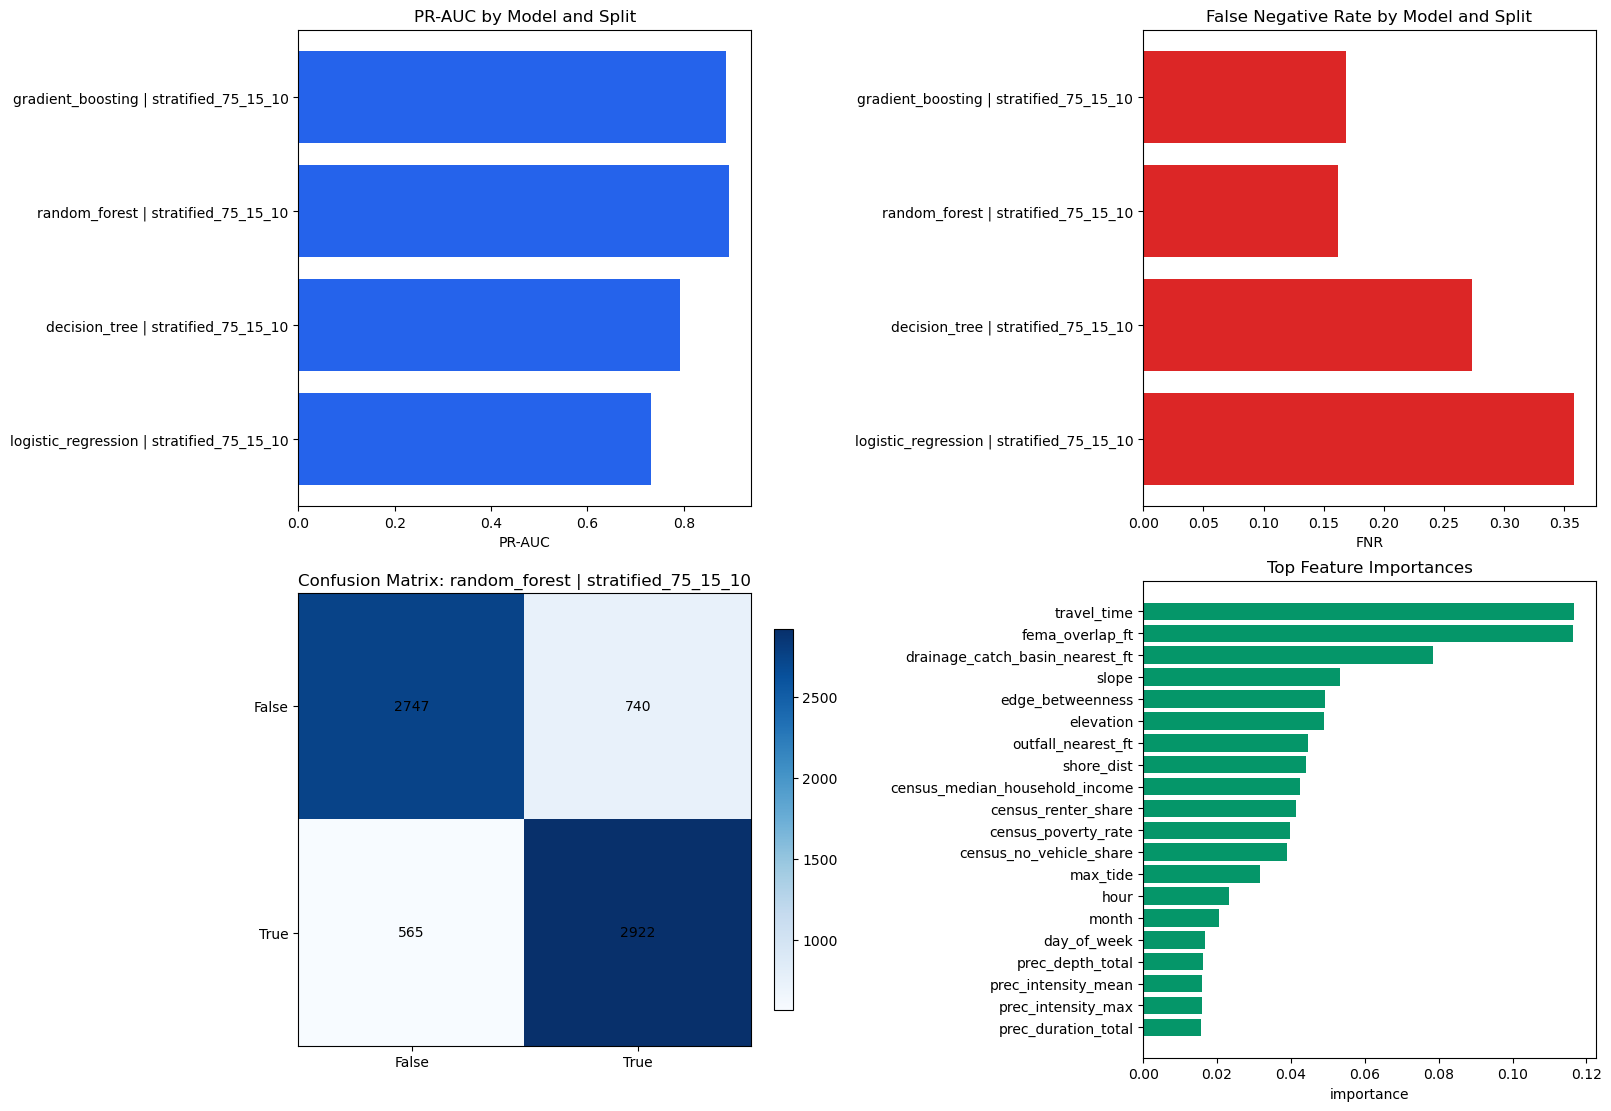

In [6]:
best_row = (
    results.query("status == 'ok'")
    .sort_values(["pr_auc", "recall", "balanced_accuracy"], ascending=False, kind="stable")
    .iloc[0]
)
best_predictions = predictions[
    (predictions["model_name"] == best_row["model_name"])
    & (predictions["split_strategy"] == best_row["split_strategy"])
    & (predictions["set_name"] == "test")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
plot_results = results.query("status == 'ok'").copy()
plot_results["label"] = plot_results["model_name"] + " | " + plot_results["split_strategy"]
axes[0, 0].barh(plot_results["label"], plot_results["pr_auc"], color="#2563EB")
axes[0, 0].set_title("PR-AUC by Model and Split")
axes[0, 0].set_xlabel("PR-AUC")

axes[0, 1].barh(plot_results["label"], plot_results["false_negative_rate"], color="#DC2626")
axes[0, 1].set_title("False Negative Rate by Model and Split")
axes[0, 1].set_xlabel("FNR")

cm = pd.crosstab(best_predictions["y_true"], best_predictions["y_pred"])
im = axes[1, 0].imshow(cm.to_numpy(), cmap="Blues")
axes[1, 0].set_title(f"Confusion Matrix: {best_row['model_name']} | {best_row['split_strategy']}")
axes[1, 0].set_xticks(range(len(cm.columns)))
axes[1, 0].set_xticklabels(cm.columns.astype(str))
axes[1, 0].set_yticks(range(len(cm.index)))
axes[1, 0].set_yticklabels(cm.index.astype(str))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1, 0].text(j, i, int(cm.iloc[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=axes[1, 0], shrink=0.8)

top_features = feature_importance.head(20).sort_values("importance", kind="stable")
axes[1, 1].barh(top_features["feature"], top_features["importance"], color="#059669")
axes[1, 1].set_title("Top Feature Importances")
axes[1, 1].set_xlabel("importance")
plt.show()

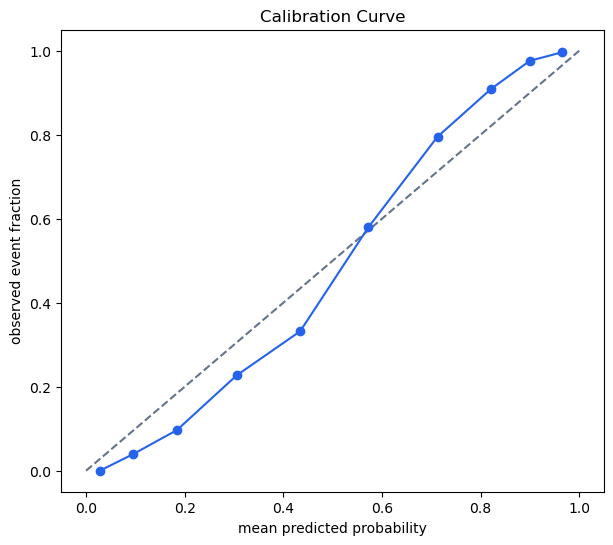

In [7]:
if not calibration.empty:
    best_calibration = calibration[
        (calibration["model_name"] == best_row["model_name"])
        & (calibration["split_strategy"] == best_row["split_strategy"])
        & (calibration["set_name"] == "test")
    ]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#64748B")
    ax.plot(
        best_calibration["mean_predicted_probability"],
        best_calibration["observed_rate"],
        marker="o",
        color="#2563EB",
    )
    ax.set_title("Calibration Curve")
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed event fraction")
    plt.show()
else:
    print("Calibration table is empty.")